In [3]:
import arviz as az
idata = az.from_netcdf('/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/model-EU_3_trace.netcdf')


In [6]:
idata.posterior['alpha_mu'].to_dataframe()

alpha_mu
chain draw alpha_regressors               
0     0    C(session)[1]          0.076695
           C(session)[2]          0.106522
           group                  0.109661
           C(session)[T.2]:group  0.226096
      1    C(session)[1]          0.028027
...                                    ...
3     998  C(session)[T.2]:group  0.036127
      999  C(session)[1]          0.120100
           C(session)[2]          0.243451
           group                 -0.053396
           C(session)[T.2]:group  0.042667

[16000 rows x 1 columns]

In [10]:
alphas = idata.posterior['alpha_mu'].to_dataframe()
def softplus_np(x): return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)

a = alphas.xs('C(session)[T.2]:group',0,'alpha_regressors')

alpha_mu    0.15825
dtype: float64

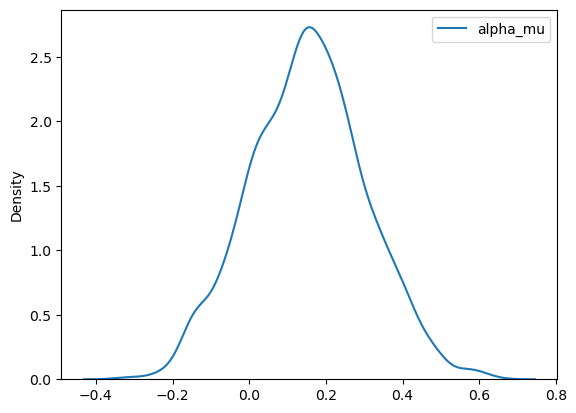

In [12]:
import seaborn as sns

sns.kdeplot(a)
(a < 0.0).mean()